In [5]:
# Ottimizzazione di portafoglio con il modello di Markowitz
## l'obiettivo è collocare il portafoglio che combina i titoli in esame sulla frontiera efficiente e osservare dove posizionarci e con quali pesi
### il dataset presenta dati originari da yahoo finance a partire dal 2018 fino ad oggi, in esame i prezzi finali adjusted per dividendi e split azionari

In [6]:
# importo le librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

#download dei dati
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'KO', 'JNJ', 'XOM', 'JPM', 'TSLA', 'DIS']
df = yf.download(tickers, start='2018-01-01', end='2026-02-09', auto_adjust=True)  # o usa Timestamp.today()

#ispeziono il dataset
df.head ()
df.shape
df.columns
df.info ()

#estraiamo i prezzi

prices= df['Close']
prices.head()

[*********************100%***********************]  10 of 10 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2036 entries, 2018-01-02 to 2026-02-06
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    2036 non-null   float64
 1   (Close, AMZN)    2036 non-null   float64
 2   (Close, DIS)     2036 non-null   float64
 3   (Close, GOOGL)   2036 non-null   float64
 4   (Close, JNJ)     2036 non-null   float64
 5   (Close, JPM)     2036 non-null   float64
 6   (Close, KO)      2036 non-null   float64
 7   (Close, MSFT)    2036 non-null   float64
 8   (Close, TSLA)    2036 non-null   float64
 9   (Close, XOM)     2036 non-null   float64
 10  (High, AAPL)     2036 non-null   float64
 11  (High, AMZN)     2036 non-null   float64
 12  (High, DIS)      2036 non-null   float64
 13  (High, GOOGL)    2036 non-null   float64
 14  (High, JNJ)      2036 non-null   float64
 15  (High, JPM)      2036 non-null   float64
 16  (High, KO)       2036 non-null   float64
 

Ticker,AAPL,AMZN,DIS,GOOGL,JNJ,JPM,KO,MSFT,TSLA,XOM
Date,,,,,,,,,,
2018-01-02,40.267071,59.450500,106.224533,53.188862,110.130829,85.901268,35.024227,78.699913,21.368668,58.185493
2018-01-03,40.260067,60.209999,106.680595,54.096317,111.182838,85.988823,34.947315,79.066154,21.150000,59.328270
2018-01-04,40.447079,60.479500,106.633087,54.306450,111.174904,87.220642,35.439541,79.762070,20.974667,59.410362
2018-01-05,40.907566,61.457001,106.053505,55.026566,112.092484,86.660728,35.431835,80.750984,21.105333,59.362488
2018-01-08,40.755627,62.343498,104.533302,55.220840,112.234879,86.788666,35.378002,80.833351,22.427334,59.629333


In [7]:
prices_normalized = (prices / prices.iloc[0]) * 100
prices_normalized.head()
prices_normalized.tail()

Ticker,AAPL,AMZN,DIS,GOOGL,JNJ,JPM,KO,MSFT,TSLA,XOM
Date,,,,,,,,,,
2026-02-02,669.304402,408.676133,98.329448,645.329141,207.223811,356.887718,212.240629,535.569818,1973.964898,234.692058
2026-02-03,667.990694,401.375923,98.112929,637.856047,209.334227,364.659212,216.635867,520.187197,1974.666831,243.730424
2026-02-04,685.367047,391.905877,100.777099,625.332154,210.564536,367.462027,217.931902,523.956955,1900.024921,250.276031
2026-02-05,683.929426,374.580534,98.818981,621.971133,213.546039,359.227270,221.200208,497.998838,1858.843045,247.715482
2026-02-06,689.407529,353.773317,102.330407,606.217666,215.521756,373.403630,222.665280,507.448517,1923.891527,252.751850


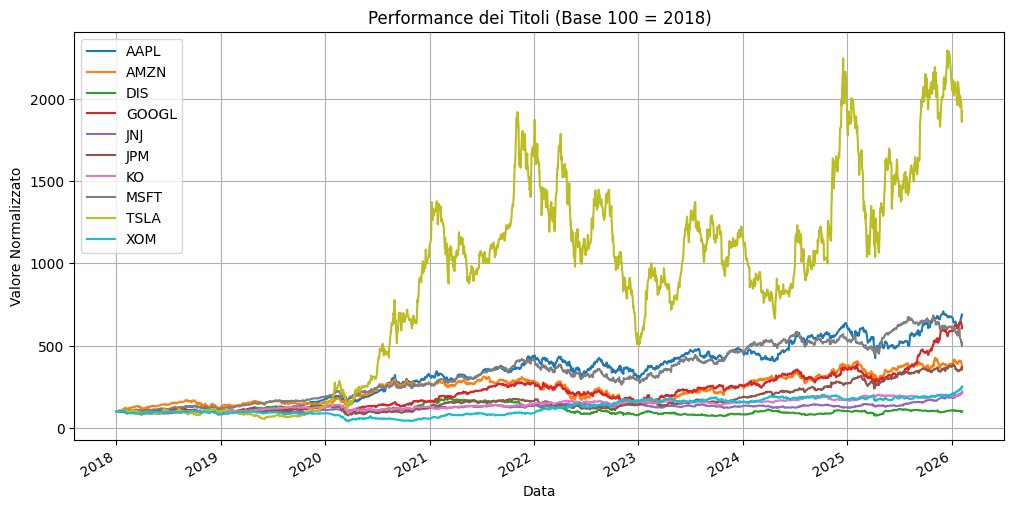

In [8]:
prices_normalized.plot(figsize=(12, 6))
plt.title('Performance dei Titoli (Base 100 = 2018)')
plt.ylabel('Valore Normalizzato')
plt.xlabel('Data')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [9]:
# calcoliamo i rendimenti logaritmici


rendimenti = np.log(prices / prices.shift(1))
rendimenti=rendimenti.dropna()
rendimenti.head()

Ticker,AAPL,AMZN,DIS,GOOGL,JNJ,JPM,KO,MSFT,TSLA,XOM
Date,,,,,,,,,,
2018-01-03,-0.000174,0.012694,0.004284,0.016917,0.009507,0.001019,-0.002198,0.004643,-0.010286,0.019450
2018-01-04,0.004634,0.004466,-0.000445,0.003877,-0.000071,0.014224,0.013987,0.008763,-0.008325,0.001383
2018-01-05,0.011321,0.016033,-0.005450,0.013173,0.008220,-0.006440,-0.000217,0.012322,0.006210,-0.000806
2018-01-08,-0.003721,0.014322,-0.014438,0.003524,0.001270,0.001475,-0.001520,0.001019,0.060755,0.004485
2018-01-09,-0.000114,0.004665,-0.000727,-0.001275,0.015733,0.005057,0.004988,-0.000680,-0.008118,-0.004255


In [10]:
# rendimenti annualizzati medi
rendimentiAM= rendimenti.mean()*252
print(rendimentiAM)
# volatilità ANNUALIZZATA
volatilità = rendimenti.std() * np.sqrt(252)
print (volatilità)
print(volatilità['AAPL'])
#matrice covarianza
matrice_cov= rendimenti.cov()*252
print(matrice_cov)


#matrice correlazione
matrice_corr= rendimenti.corr()
print(matrice_corr)


Ticker
AAPL     0.239080
AMZN     0.156461
DIS      0.002853
GOOGL    0.223155
JNJ      0.095090
JPM      0.163149
KO       0.099128
MSFT     0.201133
TSLA     0.366166
XOM      0.114823
dtype: float64
Ticker
AAPL     0.306790
AMZN     0.344113
DIS      0.307968
GOOGL    0.308818
JNJ      0.195901
JPM      0.289957
KO       0.193797
MSFT     0.285965
TSLA     0.632149
XOM      0.301896
dtype: float64
0.30678987921412393
Ticker      AAPL      AMZN       DIS     GOOGL       JNJ       JPM        KO  \
Ticker                                                                         
AAPL    0.094120  0.062301  0.041368  0.058984  0.019164  0.038432  0.021041   
AMZN    0.062301  0.118414  0.042938  0.068136  0.010367  0.032351  0.011095   
DIS     0.041368  0.042938  0.094844  0.040252  0.015919  0.049642  0.022417   
GOOGL   0.058984  0.068136  0.040252  0.095368  0.015457  0.037335  0.017140   
JNJ     0.019164  0.010367  0.015919  0.015457  0.038377  0.020141  0.019707   
JPM     0.038432

In [11]:
def rendimento_portafoglio(pesi, rendimenti_medi):
    return np.sum(pesi * rendimenti_medi)

def rischio_portafoglio(pesi, matrice_cov):
    return np.sqrt(np.dot(pesi.T, np.dot(matrice_cov, pesi)))


pesi_uguali= np.array ([0.1]*10)
rend = rendimento_portafoglio(pesi_uguali, rendimentiAM)
risk = rischio_portafoglio(pesi_uguali, matrice_cov)

print(f"Rendimento portafoglio equipesato: {rend:.2%}")
print(f"Rischio portafoglio equipesato: {risk:.2%}")

Rendimento portafoglio equipesato: 16.61%
Rischio portafoglio equipesato: 21.32%


In [12]:
from scipy.optimize import minimize

# SCENARIO 1: Minimizzare il rischio per un rendimento target

# 1. Funzione obiettivo (minimizzare rischio)
def obiettivo_scenario1(pesi):
    return rischio_portafoglio(pesi, matrice_cov)

# 2. Rendimento target
rendimento_target = 0.20  # 20% annuo

# 3. Vincoli
vincolo_somma = {
    'type': 'eq',
    'fun': lambda pesi: np.sum(pesi) - 1
}

vincolo_rendimento = {
    'type': 'ineq',
    'fun': lambda pesi: rendimento_portafoglio(pesi, rendimentiAM) - rendimento_target
}

# 4. Bounds (limiti sui pesi: tra 0 e 1)
bounds = tuple((0, 1) for _ in range(10))

# 5. Pesi iniziali
pesi_iniziali = np.array([0.1] * 10)

# 6. Ottimizzazione
risultato_s1 = minimize(
    obiettivo_scenario1,
    pesi_iniziali,
    method='SLSQP',
    bounds=bounds,
    constraints=[vincolo_somma, vincolo_rendimento]
)

# 7. Risultati
pesi_ottimali_s1 = risultato_s1.x

print("="*50)
print("SCENARIO 1: Minimizza Rischio per Rendimento ≥ 20%")
print("="*50)
print("\nPesi ottimali:")
for ticker, peso in zip(rendimentiAM.index, pesi_ottimali_s1):
    if peso > 0.01:  # mostra solo pesi > 1%
        print(f"  {ticker}: {peso:>6.2%}")

print(f"\nRendimento portafoglio: {rendimento_portafoglio(pesi_ottimali_s1, rendimentiAM):.2%}")
print(f"Rischio portafoglio: {rischio_portafoglio(pesi_ottimali_s1, matrice_cov):.2%}")
print("="*50)

SCENARIO 1: Minimizza Rischio per Rendimento ≥ 20%

Pesi ottimali:
  AAPL: 28.17%
  GOOGL: 21.52%
  JNJ: 16.57%
  JPM:  8.25%
  KO: 12.26%
  MSFT:  3.15%
  TSLA: 10.09%

Rendimento portafoglio: 20.00%
Rischio portafoglio: 22.05%


SCENARIO 2: Massimizza Rendimento per Volatilità = 25%

Pesi ottimali:
  AAPL: 36.07%
  GOOGL: 25.34%
  JNJ:  9.69%
  JPM:  9.53%
  KO:  4.45%
  MSFT:  2.27%
  TSLA: 12.65%

Rendimento portafoglio: 22.28%
Rischio portafoglio: 25.00%

CALCOLO FRONTIERA EFFICIENTE
Calcolati 50 portafogli sulla frontiera efficiente


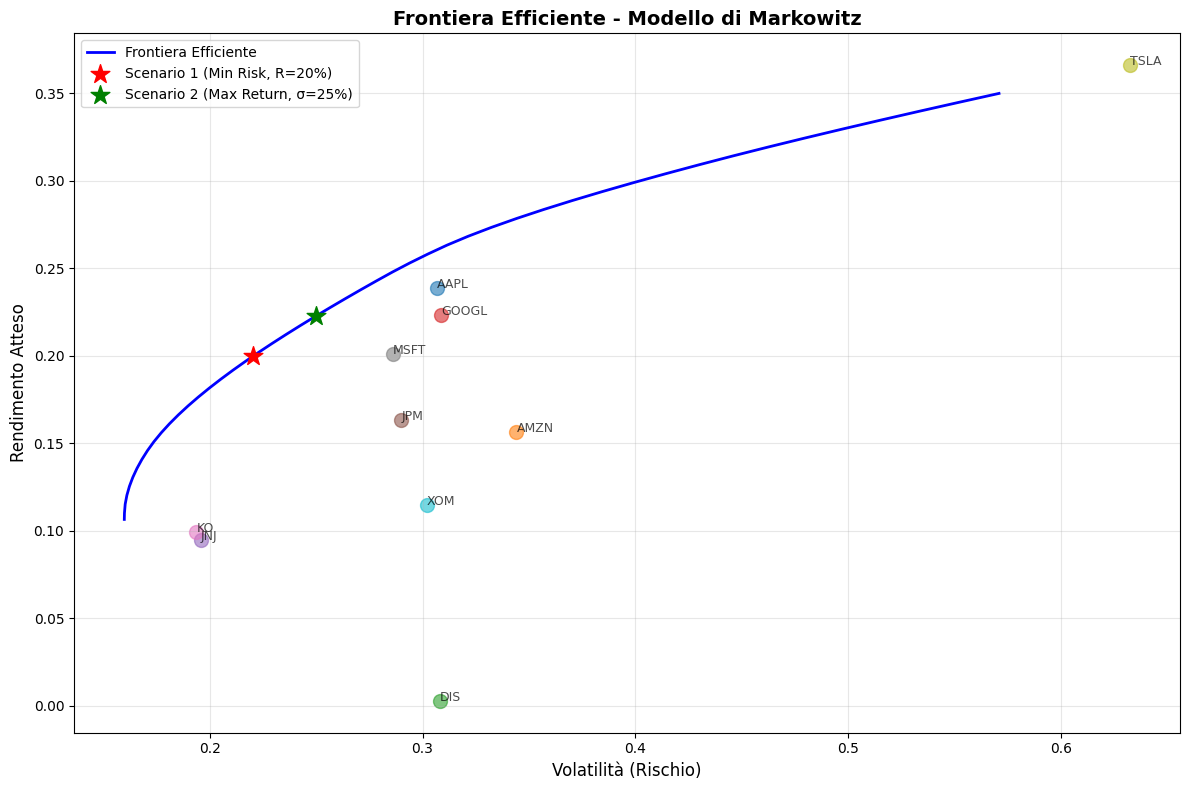

In [13]:
from scipy.optimize import minimize

# ============================================================
# SCENARIO 2: Massimizzare Rendimento per Volatilità Fissata
# ============================================================

# 1. Funzione obiettivo (massimizzare rendimento = minimizzare -rendimento)
def obiettivo_scenario2(pesi):
    return -rendimento_portafoglio(pesi, rendimentiAM)  # nota il segno negativo!

# 2. Volatilità target
volatilita_target = 0.25  # 25%

# 3. Vincoli
vincolo_somma_s2 = {
    'type': 'eq',
    'fun': lambda pesi: np.sum(pesi) - 1
}

vincolo_volatilita = {
    'type': 'eq',  # uguale esattamente alla volatilità target
    'fun': lambda pesi: rischio_portafoglio(pesi, matrice_cov) - volatilita_target
}

# 4. Bounds
bounds_s2 = tuple((0, 1) for _ in range(10))

# 5. Pesi iniziali
pesi_iniziali_s2 = np.array([0.1] * 10)

# 6. Ottimizzazione Scenario 2
risultato_s2 = minimize(
    obiettivo_scenario2,
    pesi_iniziali_s2,
    method='SLSQP',
    bounds=bounds_s2,
    constraints=[vincolo_somma_s2, vincolo_volatilita]
)

pesi_ottimali_s2 = risultato_s2.x

print("="*60)
print("SCENARIO 2: Massimizza Rendimento per Volatilità = 25%")
print("="*60)
print("\nPesi ottimali:")
for ticker, peso in zip(rendimentiAM.index, pesi_ottimali_s2):
    if peso > 0.01:
        print(f"  {ticker}: {peso:>6.2%}")

print(f"\nRendimento portafoglio: {rendimento_portafoglio(pesi_ottimali_s2, rendimentiAM):.2%}")
print(f"Rischio portafoglio: {rischio_portafoglio(pesi_ottimali_s2, matrice_cov):.2%}")
print("="*60)

# ============================================================
# FRONTIERA EFFICIENTE
# ============================================================

print("\n" + "="*60)
print("CALCOLO FRONTIERA EFFICIENTE")
print("="*60)

# Range di rendimenti target da esplorare
rendimenti_target_range = np.linspace(0.1, 0.35, 50)  # da 10% a 35%, 50 punti

# Liste per memorizzare i risultati
rischi_frontiera = []
rendimenti_frontiera = []
pesi_frontiera = []

# Per ogni rendimento target, trova il portafoglio a rischio minimo
for rend_target in rendimenti_target_range:
    # Vincoli per questa iterazione
    vincoli_temp = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w, rt=rend_target: rendimento_portafoglio(w, rendimentiAM) - rt}
    ]

    # Ottimizzazione
    risultato_temp = minimize(
        lambda w: rischio_portafoglio(w, matrice_cov),
        pesi_iniziali,
        method='SLSQP',
        bounds=bounds,
        constraints=vincoli_temp
    )

    if risultato_temp.success:
        pesi_temp = risultato_temp.x
        rischi_frontiera.append(rischio_portafoglio(pesi_temp, matrice_cov))
        rendimenti_frontiera.append(rendimento_portafoglio(pesi_temp, rendimentiAM))
        pesi_frontiera.append(pesi_temp)

print(f"Calcolati {len(rischi_frontiera)} portafogli sulla frontiera efficiente")

# ============================================================
# GRAFICO FRONTIERA EFFICIENTE
# ============================================================

plt.figure(figsize=(12, 8))

# Frontiera efficiente
plt.plot(rischi_frontiera, rendimenti_frontiera, 'b-', linewidth=2, label='Frontiera Efficiente')

# Scenario 1
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s1, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s1, rendimentiAM),
    color='red', s=200, marker='*', label='Scenario 1 (Min Risk, R=20%)', zorder=5
)

# Scenario 2
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s2, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s2, rendimentiAM),
    color='green', s=200, marker='*', label='Scenario 2 (Max Return, σ=25%)', zorder=5
)

# Titoli individuali
for ticker in rendimentiAM.index:
    plt.scatter(
        volatilità[ticker],
        rendimentiAM[ticker],
        s=100, alpha=0.6
    )
    plt.annotate(
        ticker,
        (volatilità[ticker], rendimentiAM[ticker]),
        fontsize=9, alpha=0.7
    )

plt.xlabel('Volatilità (Rischio)', fontsize=12)
plt.ylabel('Rendimento Atteso', fontsize=12)
plt.title('Frontiera Efficiente - Modello di Markowitz', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()






In [14]:
# ============================================================
# MASSIMO SHARPE RATIO (TANGENCY PORTFOLIO)
# ============================================================

print("\n" + "="*60)
print("PORTAFOGLIO A MASSIMO SHARPE RATIO")
print("="*60)

# 1. Tasso risk-free
risk_free_rate = 0.03  # 3% annuo (puoi modificarlo)

# 2. Funzione Sharpe Ratio negativo (da minimizzare)
def sharpe_negativo(pesi):
    rendimento = rendimento_portafoglio(pesi, rendimentiAM)
    rischio = rischio_portafoglio(pesi, matrice_cov)
    return -(rendimento - risk_free_rate) / rischio

# 3. Vincolo somma pesi = 1
vincolo_somma_sharpe = {
    'type': 'eq',
    'fun': lambda pesi: np.sum(pesi) - 1
}

# 4. Bounds (long only)
bounds_sharpe = tuple((0, 1) for _ in range(len(rendimentiAM)))

# 5. Ottimizzazione
risultato_sharpe = minimize(
    sharpe_negativo,
    pesi_iniziali,
    method='SLSQP',
    bounds=bounds_sharpe,
    constraints=[vincolo_somma_sharpe]
)

pesi_sharpe = risultato_sharpe.x

# 6. Risultati
rendimento_sharpe = rendimento_portafoglio(pesi_sharpe, rendimentiAM)
rischio_sharpe = rischio_portafoglio(pesi_sharpe, matrice_cov)
sharpe_ratio = (rendimento_sharpe - risk_free_rate) / rischio_sharpe

print("\nPesi ottimali (Sharpe massimo):")
for ticker, peso in zip(rendimentiAM.index, pesi_sharpe):
    if peso > 0.01:
        print(f"  {ticker}: {peso:>6.2%}")

print(f"\nRendimento atteso: {rendimento_sharpe:.2%}")
print(f"Rischio (volatilità): {rischio_sharpe:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print("="*60)






PORTAFOGLIO A MASSIMO SHARPE RATIO

Pesi ottimali (Sharpe massimo):
  AAPL: 32.22%
  GOOGL: 23.46%
  JNJ: 13.15%
  JPM:  8.82%
  KO:  8.25%
  MSFT:  2.73%
  TSLA: 11.37%

Rendimento atteso: 21.16%
Rischio (volatilità): 23.50%
Sharpe Ratio: 0.7726


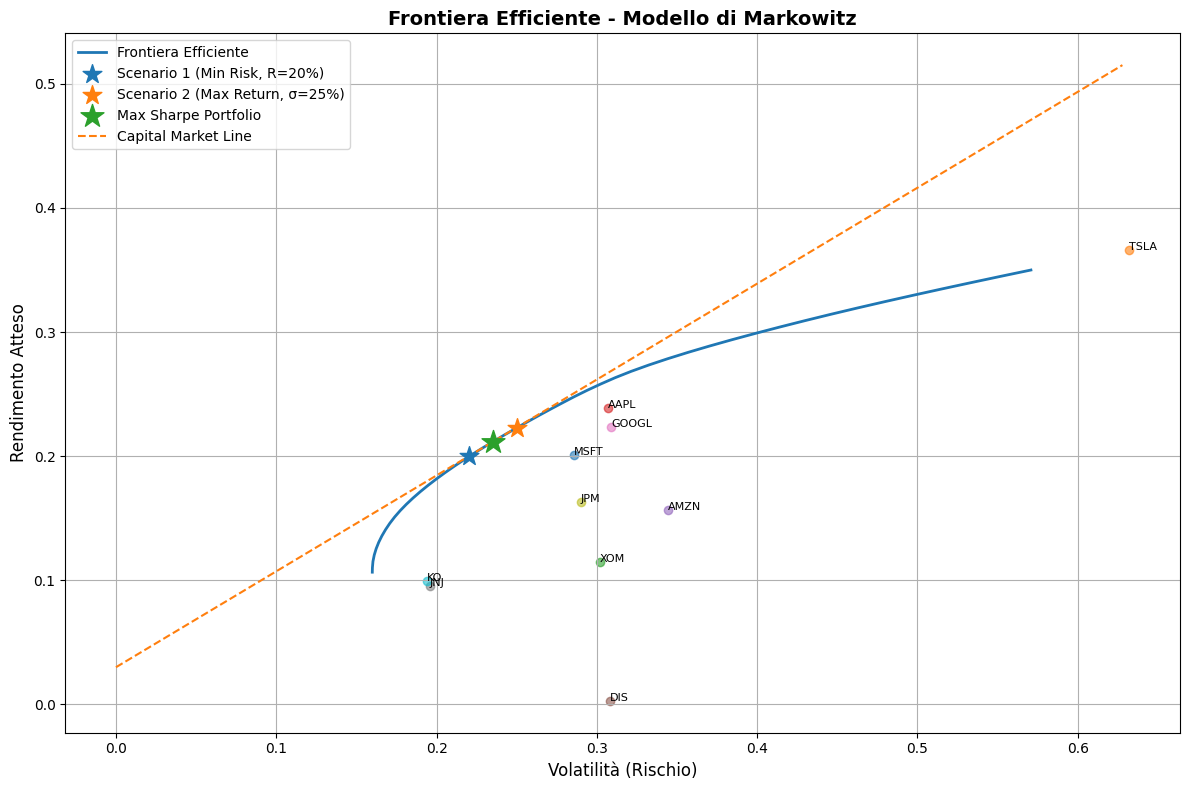

In [15]:
# ============================================================
# GRAFICO COMPLETO: FRONTIERA + MAX SHARPE + CML
# ============================================================

plt.figure(figsize=(12, 8))

# -------------------------
# Frontiera efficiente
# -------------------------
plt.plot(
    rischi_frontiera,
    rendimenti_frontiera,
    linewidth=2,
    label='Frontiera Efficiente'
)

# -------------------------
# Scenario 1
# -------------------------
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s1, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s1, rendimentiAM),
    s=200,
    marker='*',
    label='Scenario 1 (Min Risk, R=20%)',
    zorder=5
)

# -------------------------
# Scenario 2
# -------------------------
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s2, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s2, rendimentiAM),
    s=200,
    marker='*',
    label='Scenario 2 (Max Return, σ=25%)',
    zorder=5
)

# -------------------------
# Max Sharpe Portfolio
# -------------------------
plt.scatter(
    rischio_sharpe,
    rendimento_sharpe,
    s=300,
    marker='*',
    label='Max Sharpe Portfolio',
    zorder=6
)

# -------------------------
# Capital Market Line
# -------------------------
x_cml = np.linspace(0, max(rischi_frontiera)*1.1, 100)
y_cml = risk_free_rate + sharpe_ratio * x_cml

plt.plot(
    x_cml,
    y_cml,
    linestyle='--',
    label='Capital Market Line'
)

# -------------------------
# Titoli individuali
# -------------------------
for ticker in rendimentiAM.index:
    plt.scatter(
        volatilità[ticker],
        rendimentiAM[ticker],
        alpha=0.6
    )
    plt.annotate(
        ticker,
        (volatilità[ticker], rendimentiAM[ticker]),
        fontsize=8
    )

plt.xlabel('Volatilità (Rischio)', fontsize=12)
plt.ylabel('Rendimento Atteso', fontsize=12)
plt.title('Frontiera Efficiente - Modello di Markowitz', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


In [16]:
def obiettivo_scenario3(pesi):
    return rischio_portafoglio(pesi, matrice_cov)

# Constraints
vincolo_somma = {
    'type': 'eq',
    'fun': lambda pesi: np.sum(pesi) - 1
}

# Bounds
bounds = tuple((0, 1) for _ in range(len(rendimentiAM)))

# Initial weights
pesi_iniziali = np.array([1./len(rendimentiAM)] * len(rendimentiAM))

# Optimization
risultato_min_vol = minimize(
    obiettivo_scenario3,
    pesi_iniziali,
    method='SLSQP',
    bounds=bounds,
    constraints=[vincolo_somma]
)

# Extract results
pesi_min_vol = risultato_min_vol.x
rendimento_min_vol = rendimento_portafoglio(pesi_min_vol, rendimentiAM)
rischio_min_vol = rischio_portafoglio(pesi_min_vol, matrice_cov)

print("="*60)
print("SCENARIO 3: Portafoglio a Minima Volatilità (senza vincoli di rendimento)")
print("="*60)
print("\nPesi ottimali:")
for ticker, peso in zip(rendimentiAM.index, pesi_min_vol):
    if peso > 0.01:
        print(f"  {ticker}: {peso:>6.2%}")

print(f"\nRendimento atteso: {rendimento_min_vol:.2%}")
print(f"Rischio (volatilità): {rischio_min_vol:.2%}")
print("="*60)

SCENARIO 3: Portafoglio a Minima Volatilità (senza vincoli di rendimento)

Pesi ottimali:
  AMZN: 11.00%
  DIS:  2.20%
  GOOGL:  2.93%
  JNJ: 39.22%
  KO: 36.95%
  XOM:  7.70%

Rendimento atteso: 10.66%
Rischio (volatilità): 15.99%


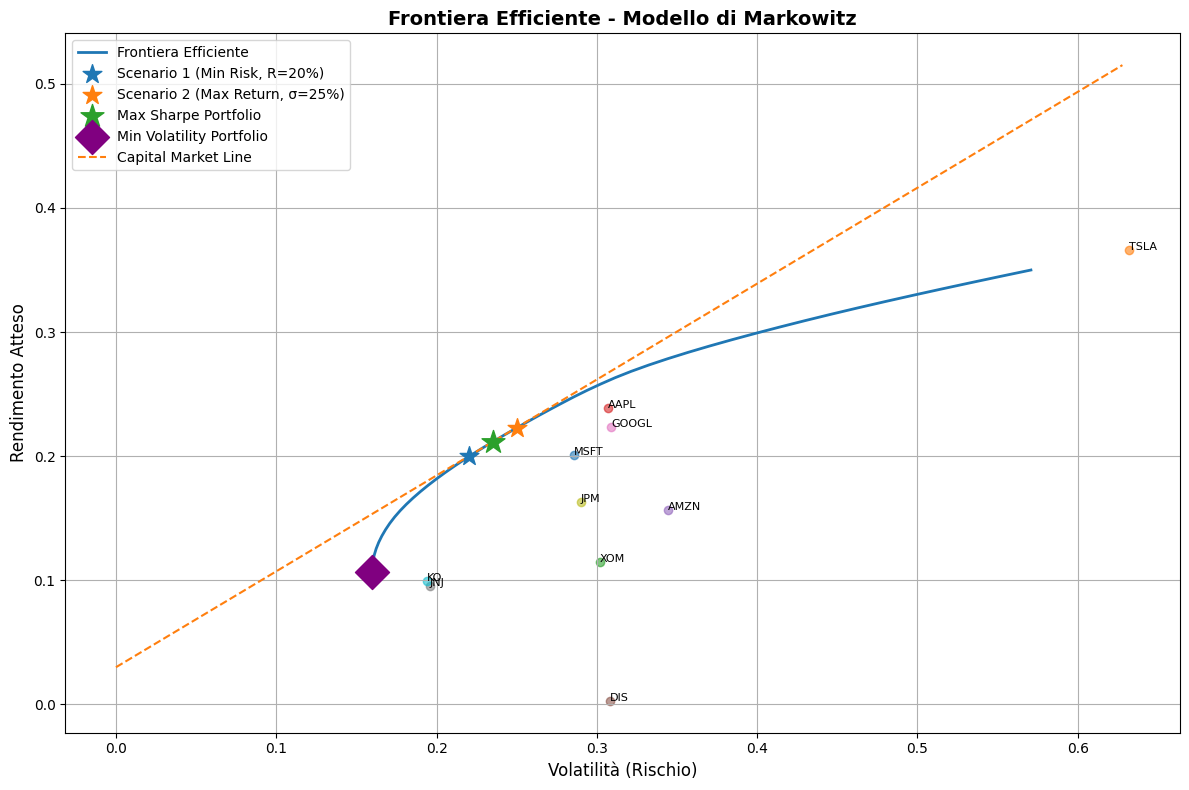

In [17]:
import matplotlib.pyplot as plt

# ============================================================
# GRAFICO COMPLETO: FRONTIERA + MAX SHARPE + CML
# ============================================================

plt.figure(figsize=(12, 8))

# -------------------------
# Frontiera efficiente
# -------------------------
plt.plot(
    rischi_frontiera,
    rendimenti_frontiera,
    linewidth=2,
    label='Frontiera Efficiente'
)

# -------------------------
# Scenario 1
# -------------------------
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s1, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s1, rendimentiAM),
    s=200,
    marker='*',
    label='Scenario 1 (Min Risk, R=20%)',
    zorder=5
)

# -------------------------
# Scenario 2
# -------------------------
plt.scatter(
    rischio_portafoglio(pesi_ottimali_s2, matrice_cov),
    rendimento_portafoglio(pesi_ottimali_s2, rendimentiAM),
    s=200,
    marker='*',
    label='Scenario 2 (Max Return, σ=25%)',
    zorder=5
)

# -------------------------
# Max Sharpe Portfolio
# -------------------------
plt.scatter(
    rischio_sharpe,
    rendimento_sharpe,
    s=300,
    marker='*',
    label='Max Sharpe Portfolio',
    zorder=6
)

# -------------------------
# Minimum Volatility Portfolio (NEW)
# -------------------------
plt.scatter(
    rischio_min_vol,
    rendimento_min_vol,
    s=300,
    marker='D',
    color='purple',
    label='Min Volatility Portfolio',
    zorder=6
)

# -------------------------
# Capital Market Line
# -------------------------
x_cml = np.linspace(0, max(rischi_frontiera)*1.1, 100)
y_cml = risk_free_rate + sharpe_ratio * x_cml

plt.plot(
    x_cml,
    y_cml,
    linestyle='--',
    label='Capital Market Line'
)

# -------------------------
# Titoli individuali
# -------------------------
for ticker in rendimentiAM.index:
    plt.scatter(
        volatilità[ticker],
        rendimentiAM[ticker],
        alpha=0.6
    )
    plt.annotate(
        ticker,
        (volatilità[ticker], rendimentiAM[ticker]),
        fontsize=8
    )

# -------------------------
# Grafica finale
# -------------------------
plt.xlabel('Volatilità (Rischio)', fontsize=12)
plt.ylabel('Rendimento Atteso', fontsize=12)
plt.title('Frontiera Efficiente - Modello di Markowitz', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Summary:

### Q&A
*   **What are the optimal weights, expected return, and risk for the minimum volatility portfolio without return constraints?**
    The optimal weights for the minimum volatility portfolio are: AMZN: 11.00%, DIS: 2.20%, GOOGL: 2.93%, JNJ: 39.22%, KO: 36.95%, and XOM: 7.70%. The expected return for this portfolio is 10.66%, and its risk (volatility) is 15.99%.

### Data Analysis Key Findings
*   The minimum volatility portfolio's optimal weights heavily concentrate on JNJ (39.22%) and KO (36.95%), indicating these assets contribute most to reducing overall portfolio risk given the covariance structure.
*   The calculated expected return for this portfolio is 10.66%, with an associated risk (volatility) of 15.99%.


### Insights or Next Steps
*   The minimum volatility portfolio serves as a crucial benchmark on the efficient frontier, representing the lowest possible risk for any portfolio composed of the given assets. Its characteristics can be compared with other optimized portfolios (e.g., maximum Sharpe ratio portfolio) to understand the trade-off between risk and return.
*   Further analysis could involve backtesting the performance of this minimum volatility portfolio against other strategies or market indices over different periods to validate its robustness and effectiveness in real-world scenarios.
